# Networks of persons in relation to organisations


Cf. [this notebook](https://github.com/Sciences-historiques-numeriques/histoire_numerique_methodes/blob/main/analyse_reseaux/reseaux_florence.ipynb) about families and power in Renaissance Florence for an introduction to network analysis with the *networkx* Python library



In [2]:
import pandas as pd


import networkx as nx
from networkx.algorithms import bipartite

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MaxNLocator

from scipy.stats import spearmanr
import statsmodels.api as sm

import numpy as np
import seaborn as sns
import math
import os

In [3]:
### this library allows to do SQL queries on dataframes
import duckdb

In [4]:
### Librairies déjà installées avec Python
import pprint
import csv

import sqlite3 as sql
import pickle

import time
import datetime
from dateutil import parser


from shutil import copyfile


In [5]:
### Importer un module de fonctions crées ad hoc
##  ATTENTION : le fichier 'sparql_functions.py' doit se trouver 
#   dans un dossier qui se situe dans le chemin ('path') de recherche
#   vu par le présent carnet Jupyter afin que
#   l'importation fonctionne correctement

import sys
from importlib import reload

# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')



In [7]:
import bivariate_library as bl

In [8]:

import network_analysis_functions as naf


In [9]:
print(reload(bl))  

<module 'bivariate_library' from '/home/my_notebooks/Jupypter_notebooks/bivariate_library.py'>


In [10]:
import warnings
warnings.filterwarnings('ignore')


## Get and inspect the data


We use in this notebook the network data prepared in these two files:
* Get the [relationships with SPARQL](https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/documentation/wikidata/data-analysis/da6-person-organisation-network.md)
* Prepare the [SQL view and export the data to CSV](https://github.com/Sciences-historiques-numeriques/astronomers/blob/main/documentation/wikidata/data-analysis/da6-person-organisation-network.sql)


Regarding persons, we reuse the file with the persons, their periods of activity and coded countries, that we created in the correspondence analysis chapter.




### Get the network data

In [11]:
### Import information about relations to organisations - df_po

csv_address='../da6_data/da6-persons-organisations-relations.csv'
df_po = pd.read_csv(csv_address)
df_po.head(3)

,person_uri,organisation_uri,organisation_label,relationship
0,http://www.wikidata.org/entity/Q1000525,http://www.wikidata.org/entity/Q834219,Bolyai University,education
1,http://www.wikidata.org/entity/Q1001016,http://www.wikidata.org/entity/Q265058,Hungarian Academy of Sciences,membership
2,http://www.wikidata.org/entity/Q1001016,http://www.wikidata.org/entity/Q390287,Eötvös Loránd University,education


In [12]:
### Inspect the dataframe and 
# notably if there are missing values
df_po.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28356 entries, 0 to 28355
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   person_uri          28356 non-null  object
 1   organisation_uri    28356 non-null  object
 2   organisation_label  28356 non-null  object
 3   relationship        28356 non-null  object
dtypes: object(4)
memory usage: 886.3+ KB


In [13]:
### Number of types of relationships
df_rela_type=pd.DataFrame(df_po.groupby(by='relationship').size())
df_rela_type.columns=['number']
df_rela_type

,number
relationship,
education,10667
employment,10413
membership,7276


### Get the data about persons

#### First: get the individuals (20000) used for correspondence analysis 


In [15]:
### Information about persons with gender, birth date,
# coded country, etc.
csv_address='../da4_data/da4_AFC.csv'
### csv_address='da_data/da2-birth-place.csv'
df_p_AFC = pd.read_csv(csv_address)
df_p_AFC.head(3)

,uriPer,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity
0,http://www.wikidata.org/entity/Q204508,Johann Michael Ackner,1782,male,Sighișoara,POINT (24.791111 46.216945),http://www.wikidata.org/entity/Q193001,1781-1790,8,Eastern Europe,RO,România,Romania,ROU,Central Europe,1827,1826-1850
1,http://www.wikidata.org/entity/Q4525913,Stanislas de Chaudoir,1790,male,Makhnivka,POINT (28.676944 49.721944),http://www.wikidata.org/entity/Q2511152,1781-1790,8,Eastern Europe,UA,Україна,Ukraine,UKR,Ukraine,1835,1826-1850
2,http://www.wikidata.org/entity/Q1063531,Charles Alfred Stothard,1786,male,London,POINT (-0.1275 51.507222),http://www.wikidata.org/entity/Q84,1781-1790,24,Northern Europe,UK,United Kingdom,United Kingdom,GBR,United Kingdom,1831,1826-1850


In [16]:
df_p_AFC=df_p_AFC[['uriPer', 'labelPer', 'birthYear', 'gender', 'labelPlace', 'REGION', 'NAME_ENGL', 'coded_country', 'periodsActivity']]

In [17]:
### Rename columns to have shorter labels
df_p_AFC.columns=['person_uri',
 'labelPer',
 'birthYear',
 'gender',
 'labelPlace',
 'REGION',
 'NAME_ENGL',
 'country',
 'per_activ'
 ]

In [18]:
### Inspect the dataframe and 
# notably if there are missing values
df_p_AFC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9936 entries, 0 to 9935
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   person_uri  9936 non-null   object
 1   labelPer    9936 non-null   object
 2   birthYear   9936 non-null   int64 
 3   gender      9936 non-null   object
 4   labelPlace  9936 non-null   object
 5   REGION      9936 non-null   object
 6   NAME_ENGL   9936 non-null   object
 7   country     9936 non-null   object
 8   per_activ   9936 non-null   object
dtypes: int64(1), object(8)
memory usage: 698.8+ KB


#### Second: get the individuals (8000) used for clustering


In [19]:
file_address='../da5_data/da5-MCA-clusters.csv'
df_p_MCA = pd.read_csv(file_address)
df_p_MCA.head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,...,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,education_place
0,http://www.wikidata.org/entity/Q204508,Johann Michael Ackner,1782,male,Sighișoara,POINT (24.791111 46.216945),http://www.wikidata.org/entity/Q193001,1781-1790,8,Eastern Europe,...,România,Romania,ROU,Central Europe,1827.0,1826-1850,9029,archaeologist,other,University of Göttingen
1,http://www.wikidata.org/entity/Q529604,Jacques Viger,1787,male,Montreal,POINT (-73.586841 45.503343),http://www.wikidata.org/entity/Q340,1781-1790,23,Northern America,...,Canada-Canada,Canada,CAN,United States Can.,1832.0,1826-1850,12996,archaeologist,historian,other_uni
2,http://www.wikidata.org/entity/Q567735,Charles Robert Cockerell,1788,male,London,POINT (-0.1275 51.507222),http://www.wikidata.org/entity/Q84,1781-1790,24,Northern Europe,...,United Kingdom,United Kingdom,GBR,United Kingdom,1833.0,1826-1850,13896,archaeologist,anthropologist,other_uni


In [22]:
print(df_p_MCA.columns.to_list())

['person_uri', 'labelPer', 'birthYear', 'gender', 'labelPlace', 'geometry', 'uriPlace', 'periods', 'FID', 'REGION', 'CNTR_ID', 'CNTR_NAME', 'NAME_ENGL', 'ISO3_CODE', 'coded_country', 'activityYear', 'periodsActivity', 'pk_person_features', 'occupation_main', 'occupation_sec1', 'education_place']


In [23]:
### Rename columns to have shorter labels
df_p_MCA.columns=['person_uri',
 'labelPer',
 'birthYear',
 'gender',
 'labelPlace',
 'geometry',
 'uriPlace',
 'periods',	
 'FID',
 'REGION',
 'CNTR_ID',
 'CNTR_NAME',
 'NAME_ENGL',
 'ISO3_CODE',
 'country',
 'activityYear',
 'per_activ',
 'pk_person_features',
 'occup_m',
 'occup_s',
 'edpl']

In [24]:
df_p_MCA=df_p_MCA[['person_uri',
 'occup_m',
 'occup_s',
 'edpl']
]

In [25]:
### Inspect the dataframe and 
# notably if there are missing values
df_p_MCA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1713 entries, 0 to 1712
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   person_uri  1713 non-null   object
 1   occup_m     1713 non-null   object
 2   occup_s     1713 non-null   object
 3   edpl        1713 non-null   object
dtypes: object(4)
memory usage: 53.7+ KB


#### Third: add the additional NCA features to the first dataframe

In [26]:
df_p=df_p_AFC.merge(df_p_MCA, left_on=['person_uri'], right_on=['person_uri'], how='left')
df_p=df_p.fillna('')

In [27]:
print(len(df_p))
df_p.iloc[:3]

9936


,person_uri,labelPer,birthYear,gender,labelPlace,REGION,NAME_ENGL,country,per_activ,occup_m,occup_s,edpl
0,http://www.wikidata.org/entity/Q204508,Johann Michael Ackner,1782,male,Sighișoara,Eastern Europe,Romania,Central Europe,1826-1850,archaeologist,other,University of Göttingen
1,http://www.wikidata.org/entity/Q4525913,Stanislas de Chaudoir,1790,male,Makhnivka,Eastern Europe,Ukraine,Ukraine,1826-1850,,,
2,http://www.wikidata.org/entity/Q1063531,Charles Alfred Stothard,1786,male,London,Northern Europe,United Kingdom,United Kingdom,1826-1850,,,


We can observe the limits a restriction to persons that only have the additional features: 

if we restrict to persons with MCA features, Albert Einstein would not be taken into account in the analysis of the network!

We cannot proceed with adding insights from clustering to the network: additional information should be first added to our information system.

We could just add the main occupation, with additional preparation (not yet implemented).


In [64]:
### Find Albert Einstein
duckdb.query("""
select *
from df_p
where labelPer like '%Bandi%'
""").to_df()

,person_uri,labelPer,gender,birthYear,country,per_activ
0,http://www.wikidata.org/entity/Q471179,Ranuccio Bianchi Bandinelli,male,1900,Italy,1926-1950


## Inspect the features of the relationships

### Distribution of relationships per country

#### Writing SQL queries with the duckdb library

In [30]:
### Distribution of coded countries
# using the duckdb library and a SQL query

# the result is the same as in the cell below
dfc=duckdb.query("""
    SELECT country, COUNT(*) as num
    FROM df_p
    GROUP BY country
    ORDER BY num DESC
  """).to_df()
dfc

,country,num
0,Germany,1629
1,France,1213
2,Italy,999
3,Czechia,786
4,Central Europe,656
5,Russian Federation,651
6,United Kingdom,639
7,Spain Port.,638
8,United States Can.,632
9,Austria Hungary,531


In [31]:
### Distribution of coded countries
dfc=pd.DataFrame(df_p.groupby(by=['country']).size())
dfc.sort_values(by=0,ascending=False)


,0
country,
Germany,1629
France,1213
Italy,999
Czechia,786
Central Europe,656
Russian Federation,651
United Kingdom,639
Spain Port.,638
United States Can.,632


## Merge the two dataframes

This will restrict the information about relations to the persons that are present in the file with the individuals (*da4-AFC.csv* with additional information from *da5-MCA-clusters.csv*)

In [32]:
df_p=df_p[['person_uri', 'labelPer', 'gender', 'birthYear','country', 'per_activ']]
df_p.head(3)

,person_uri,labelPer,gender,birthYear,country,per_activ
0,http://www.wikidata.org/entity/Q204508,Johann Michael Ackner,male,1782,Central Europe,1826-1850
1,http://www.wikidata.org/entity/Q4525913,Stanislas de Chaudoir,male,1790,Ukraine,1826-1850
2,http://www.wikidata.org/entity/Q1063531,Charles Alfred Stothard,male,1786,United Kingdom,1826-1850


In [33]:
### Merge the two dataframes:
# only relations that involve persons in df_p
# will remain
df_rel=df_po.merge(df_p,on='person_uri')
print(len(df_rel))
df_rel.head(2)

19148


,person_uri,organisation_uri,organisation_label,relationship,labelPer,gender,birthYear,country,per_activ
0,http://www.wikidata.org/entity/Q1000525,http://www.wikidata.org/entity/Q834219,Bolyai University,education,Géza Ferenczi,male,1924,Central Europe,1951-1975
1,http://www.wikidata.org/entity/Q1001016,http://www.wikidata.org/entity/Q265058,Hungarian Academy of Sciences,membership,Nándor Fettich,male,1900,Austria Hungary,1926-1950


### Inspect the merge result

In [34]:
### Unique persons
unique_p=pd.DataFrame(df_rel['person_uri'].unique())
unique_p.columns=['person_uri']
len_up=len(unique_p)
print(f"Number of persons with relations: {len_up}")
unique_p.head(2)

Number of persons with relations: 6543


,person_uri
0,http://www.wikidata.org/entity/Q1000525
1,http://www.wikidata.org/entity/Q1001016


In [35]:
### Number of types of relationships and per person proportion
df_rela_type=pd.DataFrame(df_rel.groupby(by='relationship').size())
df_rela_type.columns=['number']
df_rela_type['propr_rela_per_person']=df_rela_type['number'].apply(lambda x : x/len_up)
df_rela_type

,number,propr_rela_per_person
relationship,,
education,6671,1.019563
employment,6527,0.997555
membership,5950,0.909369


### Restriction to persons with memberships

We observe from the former queries, that some persons have no memberships. 

In our analysis of the field, notably with a question about correlation  we decide 


In [36]:
###  Count number of relations per person
df_rel = duckdb.query("""
    with tw1 AS (
    -- we create a list of persons with memberships
    SELECT DISTINCT person_uri
    FROM df_rel
    WHERE relationship='membership'
    )
    SELECT *
    FROM df_rel 
    WHERE person_uri IN (SELECT person_uri FROM tw1)
    
""").to_df()
print(len(df_rel))
df_rel.iloc[:2]

11495


,person_uri,organisation_uri,organisation_label,relationship,labelPer,gender,birthYear,country,per_activ
0,http://www.wikidata.org/entity/Q12078639,http://www.wikidata.org/entity/Q2991053,Shevchenko Scientific Society,membership,Kateryna Antonovych-Melnyk,female,1859,Ukraine,1901-1925
1,http://www.wikidata.org/entity/Q12086203,http://www.wikidata.org/entity/Q27621,Saint Petersburg State University,education,Serhii Bibikov,male,1908,Ukraine,1951-1975


In [37]:
###  Count number of relations per person
duckdb.query("""
    WITH tw1 AS (
    -- we create a list of unique persons
    SELECT DISTINCT person_uri
    FROM df_rel
    )
    SELECT relationship, COUNT(*) as number, 
            ROUND(COUNT(*)/(SELECT COUNT(*) FROM tw1),2) AS propr_rela_per_person
    FROM df_rel 
    GROUP BY relationship
    ORDER BY relationship    
""").to_df()

,relationship,number,propr_rela_per_person
0,education,2589,0.90
1,employment,2956,1.02
2,membership,5950,2.06


### Number of relationships per person

In [38]:
###  Count number of relations per person
print('Number of relations per person:')
df_pn = duckdb.query("""
    with tw1 AS (
    SELECT person_uri, COUNT(*) as number
    FROM df_rel
    GROUP BY person_uri
    )
    SELECT labelPer,number, birthYear,country,per_activ, tw1.person_uri
    from tw1 join df_p on df_p.person_uri = tw1.person_uri
    ORDER BY number DESC
""").to_df()
df_pn.iloc[:8]

Number of relations per person:


,labelPer,number,birthYear,country,per_activ,person_uri
0,Jean Leclant,29,1920,France,1951-1975,http://www.wikidata.org/entity/Q329349
1,Tadeusz Stefan Zieliński,29,1859,Ukraine,1901-1925,http://www.wikidata.org/entity/Q694826
2,Michael Rostovtzeff,26,1870,Ukraine,1901-1925,http://www.wikidata.org/entity/Q502983
3,Rudolf Virchow,25,1821,Poland,1851-1875,http://www.wikidata.org/entity/Q76432
4,Ivan Łuckievič,21,1881,Baltic States Fin. Belar.,1926-1950,http://www.wikidata.org/entity/Q168867
5,William Ramsay,21,1852,United Kingdom,1876-1900,http://www.wikidata.org/entity/Q950726
6,Salvatore Settis,18,1941,Italy,1976-2000,http://www.wikidata.org/entity/Q520802
7,Léon Heuzey,18,1831,France,1876-1900,http://www.wikidata.org/entity/Q709657


In [39]:
### Statistical profile
print(df_pn.number.describe())

count    2885.000000
mean        3.984402
std         2.893887
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        29.000000
Name: number, dtype: float64


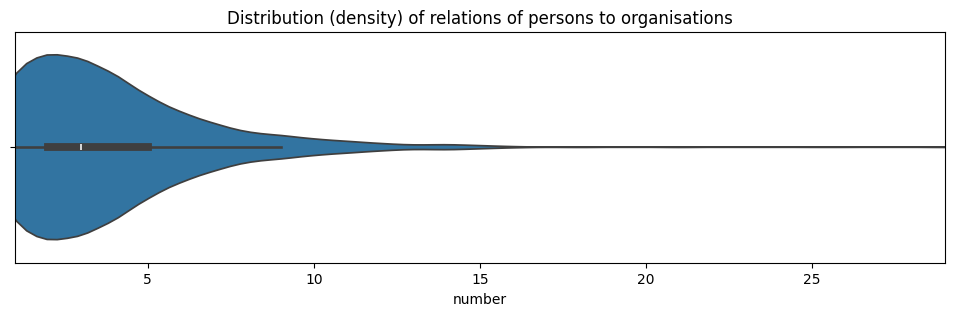

In [40]:
# Plot the distribution number of relations to organisations

min_val = df_pn.number.min()
max_val = df_pn.number.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df_pn.number, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

### Inspect the persons with a high number of relationships

In [41]:
### Persons that have 10 or more relations to organisations
print(len(df_pn[df_pn.number > 9]))

148


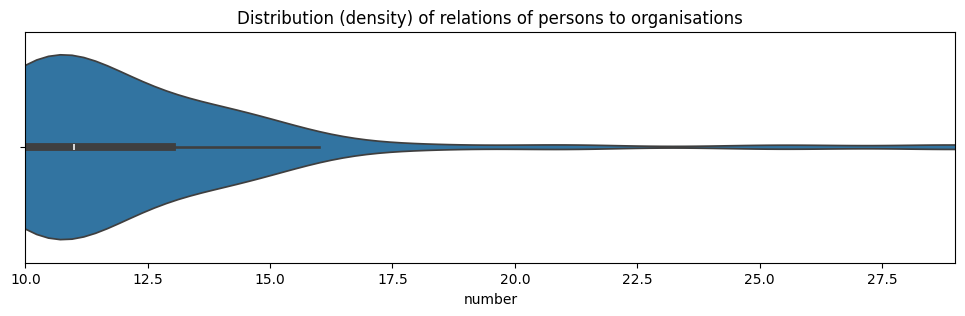

In [42]:
# Plot the distribution number of relations to organisations

df=df_pn[df_pn.number > 9]

min_val = df.number.min()
max_val = df.number.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df.number, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

In [43]:
### Number of types of relationships, all the persons
df_rela_type=pd.DataFrame(df_rel.groupby(by='relationship').size())
df_rela_type.columns=['number']

### Type of relationship of the 700 more connected persons (merge on the fly)
df_pn[df_pn.number > 9].merge(df_rel, left_on='person_uri', right_on='person_uri').groupby(by='relationship').size()

df_rela_type=df_rela_type.join((df_pn[df_pn.number > 9].\
                   merge(df_rel, left_on='person_uri', right_on='person_uri').groupby(by='relationship').size()).rename('rel_700'))

### Add the proportion between all the relations and those of the most connected persons
df_rela_type['prop']=df_rela_type.apply(lambda x: x['rel_700']/x['number'], axis=1)
### We observe that memberships are overrepresented for this very well known persons
df_rela_type


,number,rel_700,prop
relationship,,,
education,2589,339,0.130939
employment,2956,454,0.153586
membership,5950,1030,0.173109


## Relationships with organisations in relation to activity periods

Observe if periods are specific to relations and which ones 

In [44]:
### Distribution of RELATIONS by periods of activity
activities_per = pd.DataFrame(df_rel.groupby(by='per_activ').size())
activities_per.columns=['number_rel']
print(activities_per)

           number_rel
per_activ            
1826-1850         613
1851-1875         948
1876-1900        1384
1901-1925        1730
1926-1950        1872
1951-1975        1935
1976-2000        2225
2001-2025         788


In [45]:
### Distribution of PERSONS by periods of activity
period_per = pd.DataFrame(df_p.groupby(by='per_activ').size())
period_per.columns=['number_per']
print(period_per)

           number_per
per_activ            
1826-1850         316
1851-1875         540
1876-1900         804
1901-1925        1041
1926-1950        1219
1951-1975        1791
1976-2000        2519
2001-2025        1706


In [46]:
df_ap_per=activities_per.join(period_per)

### Number of activities divided by number of persons
df_ap_per['proportion']=df_ap_per.apply(lambda x: x.number_rel/x.number_per, axis=1).round(3)
df_ap_per

,number_rel,number_per,proportion
per_activ,,,
1826-1850,613,316,1.940
1851-1875,948,540,1.756
1876-1900,1384,804,1.721
1901-1925,1730,1041,1.662
1926-1950,1872,1219,1.536
1951-1975,1935,1791,1.080
1976-2000,2225,2519,0.883
2001-2025,788,1706,0.462


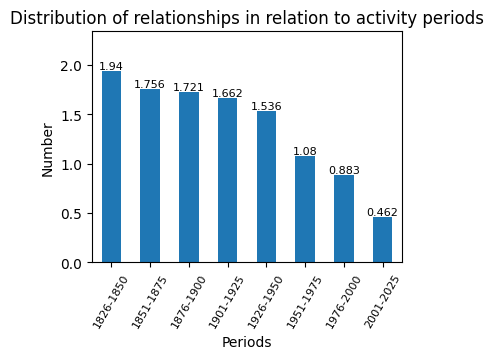

In [47]:
### Plot the evolution in time


ax = df_ap_per.proportion.plot(kind='bar',rot=50, fontsize=10, figsize=(4,3))
ax.bar_label(ax.containers[-1], size=8)


current_min, current_max = ax.get_ylim()
ax.set_ylim(current_min, current_max+0.3)

# Rotate labels 60 degrees and reduce font size
plt.xticks(rotation=60, fontsize=8)

plt.ylabel('Number')
plt.xlabel('Periods')
plt.title('Distribution of relationships in relation to activity periods')
plt.show()

In [48]:
### Create a cross-table
crosstab = pd.crosstab(df_rel['per_activ'],df_rel['relationship'])
# Optional: Remove the index name if you want a cleaner look
# crosstab.index.name = None
crosstab.columns.name = None
crosstab


,education,employment,membership
per_activ,,,
1826-1850,88,60,465
1851-1875,173,113,662
1876-1900,297,246,841
1901-1925,384,427,919
1926-1950,437,539,896
1951-1975,476,545,914
1976-2000,530,736,959
2001-2025,204,290,294


In [49]:
bl.check_chi_square_test_validity(crosstab)

Table valid for Chi-square test: True


In [50]:
expected=bl.bivariate_stats(crosstab)

Chi-square : 525.83 , dof : 14
p-value : 0.0
Inertia (Phi-square):  0.046
Cramer:  0.151


#### Comment

A relation appears between type of relationship and period, but it is weak. As we can observe in the heatmap of adjusted residuals: membership tends to be proportionally more present in the 19th century, while study and employment are more present in the 20th century. 

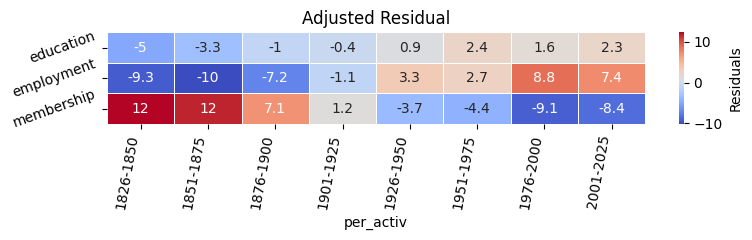

In [51]:
pp = bl.plot_chi2_residuals(crosstab.T, figsize=(8, 2.5))

## Relationships with organisations in relation to periods: analysis per relationship type

### Universities - education

In [52]:
### Create a cross-table for inspection
df=df_rel[df_rel['relationship']=='education']
# Create the crosstab
crosstab = pd.crosstab(df['organisation_label'],df['per_activ'])

# Optional: Remove the index name if you want a cleaner look
crosstab.index.name = None
# crosstab.columns.name = None

crosstab=crosstab.fillna(0)
crosstab=crosstab.astype(int)
crosstab['sum'] = crosstab.sum(axis=1)

In [53]:
### Evolution of number of students in major universities (population in Wikidata)
print('Number of persons per organisation and period:', len(crosstab))
## We take only the 20 organisations with more relationships
cct=crosstab.sort_values(by='sum',ascending=False).iloc[:20]
cct


Number of persons per organisation and period: 804


per_activ,1826-1850,1851-1875,1876-1900,1901-1925,1926-1950,1951-1975,1976-2000,2001-2025,sum
École Normale Supérieure,1,3,9,19,10,15,16,1,74
University of Vienna,2,2,8,18,8,9,10,7,64
University of Bonn,0,4,18,14,1,7,3,5,52
Ludwig-Maximilians-Universität München,1,1,8,8,3,4,13,7,45
Humboldt-Universität zu Berlin,2,9,8,12,6,2,4,0,43
Leipzig University,4,8,9,12,3,3,1,1,41
École pratique des hautes études,0,0,3,7,6,13,11,0,40
Harvard University,0,0,5,6,14,8,5,0,38
Italian School of Archaeology at Athens,0,0,0,0,15,13,6,1,35
University of Göttingen,4,6,11,3,2,1,5,2,34


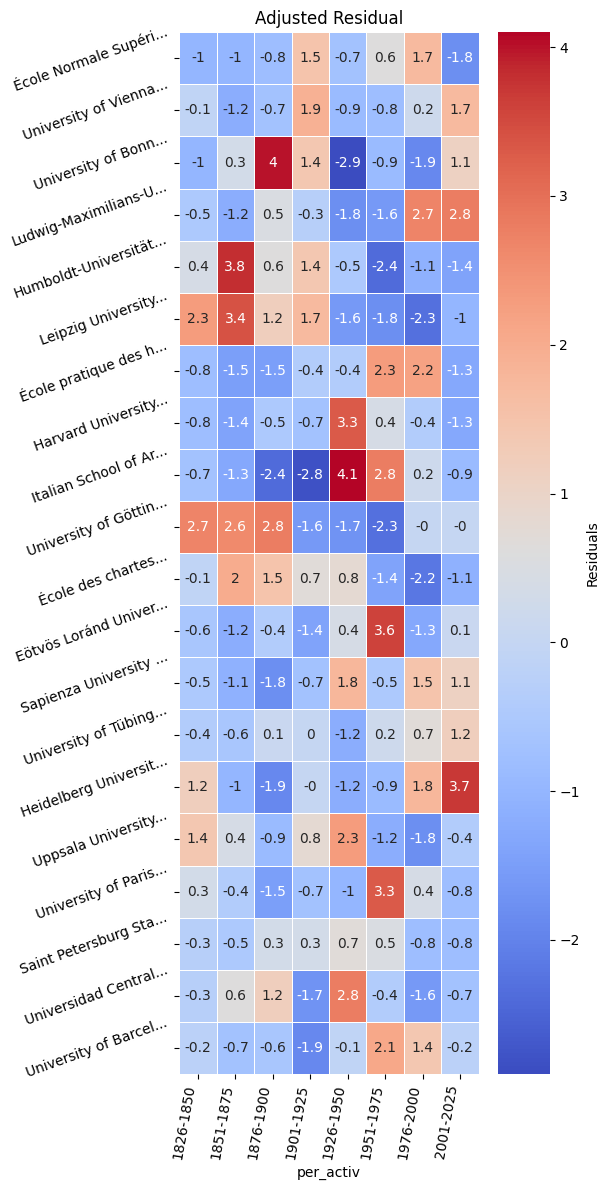

In [54]:
### Specific periods with the residuals heatmap on the corrtable
cct.index=[e[:20]+'...' for e in cct.index]
pp = bl.plot_chi2_residuals(cct.iloc[:,:-1], figsize=(6,12))

### Employers

In [55]:
### Create a cross-table for inspection
df=df_rel[df_rel['relationship']=='employment']
# Create the crosstab
crosstab = pd.crosstab(df['organisation_label'],df['per_activ'])

# Optional: Remove the index name if you want a cleaner look
crosstab.index.name = None
# crosstab.columns.name = None

crosstab=crosstab.fillna(0)
crosstab=crosstab.astype(int)
crosstab['sum'] = crosstab.sum(axis=1)

### Evolution of number of students in major universities (population in Wikidata)
print('Number of persons per organisation and period:', len(crosstab))
cct=crosstab.sort_values(by='sum',ascending=False).iloc[:20]
cct

Number of persons per organisation and period: 947


per_activ,1826-1850,1851-1875,1876-1900,1901-1925,1926-1950,1951-1975,1976-2000,2001-2025,sum
University of Vienna,3,0,8,14,10,7,18,7,67
Humboldt-Universität zu Berlin,2,5,10,15,12,3,9,4,60
Collège de France,4,7,5,15,7,6,6,0,50
Ludwig-Maximilians-Universität München,2,1,4,7,3,9,12,7,45
University of Göttingen,2,5,10,2,10,6,7,1,43
University of Bonn,0,3,4,7,4,7,12,3,40
Heidelberg University,1,1,2,5,6,9,10,6,40
Sapienza University of Rome,2,0,3,6,12,6,9,0,38
University of Tübingen,0,2,2,3,4,7,11,9,38
École française de Rome,0,1,2,8,6,6,12,1,36


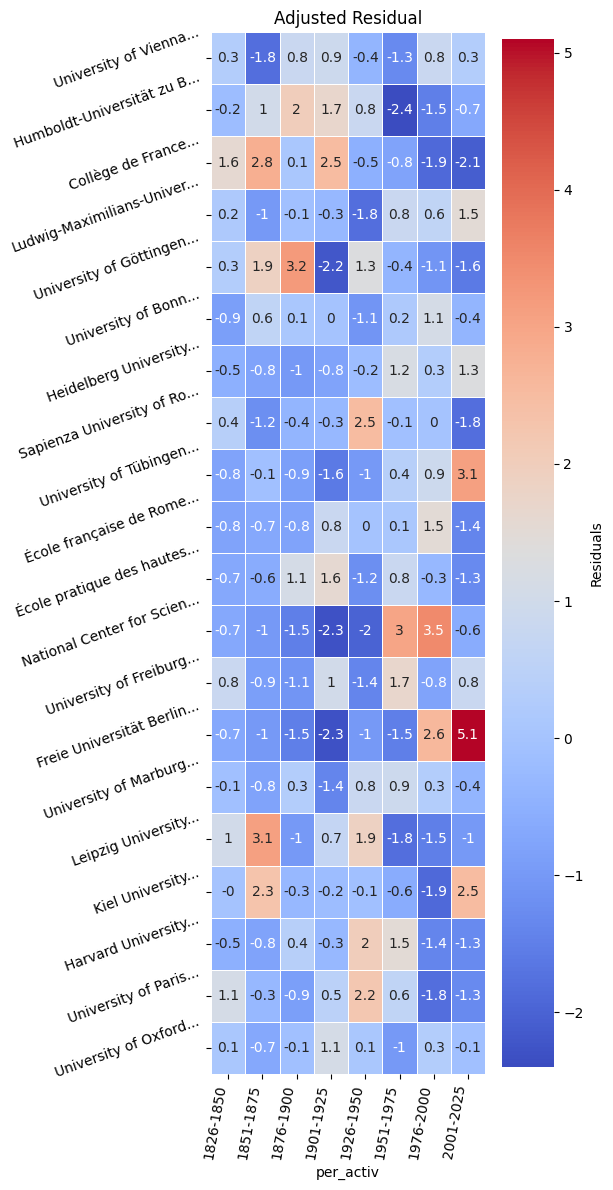

In [56]:
cct.index=[e[:25]+'...' for e in cct.index]
pp = bl.plot_chi2_residuals(cct.iloc[:,:-1], figsize=(6,12))

### Memberships

In [57]:
### Create a cross-table for inspection
df=df_rel[df_rel['relationship']=='membership']
# Create the crosstab
crosstab = pd.crosstab(df['organisation_label'],df['per_activ'])

# Optional: Remove the index name if you want a cleaner look
crosstab.index.name = None
# crosstab.columns.name = None

crosstab=crosstab.fillna(0)
crosstab=crosstab.astype(int)
crosstab['sum'] = crosstab.sum(axis=1)

### Evolution of number of students in major universities (population in Wikidata)
print('Number of persons per organisation and period:', len(crosstab))
cct=crosstab.sort_values(by='sum',ascending=False).iloc[:20]
cct

Number of persons per organisation and period: 1061


per_activ,1826-1850,1851-1875,1876-1900,1901-1925,1926-1950,1951-1975,1976-2000,2001-2025,sum
German Archaeological Institute,22,18,61,106,118,178,205,58,766
Académie des Inscriptions et Belles-Lettres,24,30,24,55,39,29,33,1,235
Accademia Nazionale dei Lincei,0,18,24,32,41,39,27,4,185
"Royal Swedish Academy of Letters, History and Antiquities",16,29,29,27,32,19,7,2,161
Academy of Sciences of Turin,35,28,18,7,4,7,8,0,107
Royal Prussian Academy of Sciences,19,23,28,22,7,0,0,0,99
Göttingen Academy of Sciences and Humanities in Lower Saxony,8,20,17,19,17,10,5,0,96
American Academy of Arts and Sciences,4,7,12,9,16,28,15,3,94
Bavarian Academy of Sciences and Humanities,12,16,11,18,14,12,5,4,92
Society of Antiquaries of London,2,9,10,8,14,23,19,7,92


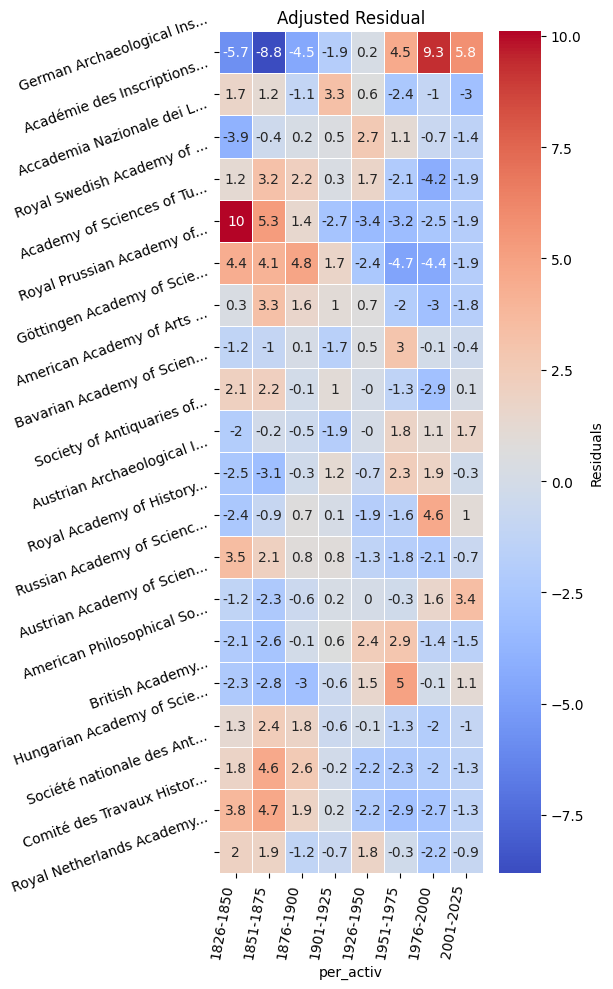

In [58]:
cct.index=[e[:25]+'...' for e in cct.index]
pp = bl.plot_chi2_residuals(cct.iloc[:,:-1], figsize=(6,10))

## Add years to approximate possible relations


In this exercice we artificially build relationships between persons without providing a measure of their real match to reality. In a heuristic perspective, the aim is just to have a consistent network in view of applying some analysis techniques.


We model artificial or imputed encounters based on the idea that persons present in the same institutions in the same period virtually know each other. But this is not alway the case although it allows to build person networks around organisations.

In [59]:
### fonction that codes the year of begin of an 'encounter'
def code_year_begin(type_relation, year):
    if type_relation=='education':
        begin=int(year)+20
    elif type_relation=='employment':
        begin=int(year)+28
    elif type_relation=='membership':
        begin=int(year)+40
    else :
        begin = 0

    return begin    

In [60]:
### function that codes the year of end of the virtual "encounter"
def code_year_end(type_relation, year):
    if type_relation=='education':
        end=int(year)+28
    elif type_relation=='employment':
        end=int(year)+65
    elif type_relation=='membership':
        end=int(year)+65
    else :
        end = 0
        
    return end

In [61]:
### Apply the functions 
df_rel['year_begin'] = df_rel.apply(lambda x : code_year_begin(x['relationship'], x['birthYear']), axis=1)
df_rel['year_end'] = df_rel.apply(lambda x : code_year_end(x['relationship'], x['birthYear']), axis=1)

In [62]:
### Inspect the coding
df_rel[df_rel.relationship=='membership'].iloc[10:15]

,person_uri,organisation_uri,organisation_label,relationship,labelPer,gender,birthYear,country,per_activ,year_begin,year_end
36,http://www.wikidata.org/entity/Q121278,http://www.wikidata.org/entity/Q684415,Bavarian Academy of Sciences and Humanities,membership,Friedrich Wilhelm von Bissing,male,1873,Germany,1901-1925,1913,1938
37,http://www.wikidata.org/entity/Q121278,http://www.wikidata.org/entity/Q695302,German Archaeological Institute,membership,Friedrich Wilhelm von Bissing,male,1873,Germany,1901-1925,1913,1938
38,http://www.wikidata.org/entity/Q12139093,http://www.wikidata.org/entity/Q2991053,Shevchenko Scientific Society,membership,Yaroslav Pasternak,male,1892,Ukraine,1926-1950,1932,1957
42,http://www.wikidata.org/entity/Q12139397,http://www.wikidata.org/entity/Q2991053,Shevchenko Scientific Society,membership,Пелещишин Микола Андрійович,male,1933,Poland,1976-2000,1973,1998
45,http://www.wikidata.org/entity/Q1214220,http://www.wikidata.org/entity/Q265058,Hungarian Academy of Sciences,membership,Géza Nagy,male,1855,Austria Hungary,1876-1900,1895,1920


## Create pairs of persons: education

Create relations of persons through relations to organisations

In [65]:
### Select the columns that will be used
df_sel = df_rel[df_rel.relationship=='education'][['person_uri','labelPer','organisation_uri', 'organisation_label', 'year_begin','year_end', 'per_activ']].copy(deep=True)
### Order by person_uri
df_sel=df_sel.sort_values(by='person_uri')
print(len(df_sel))

2589


In [66]:
### Join on common organisation: cartesian product -> produces a lot of rows !
merged_edu = pd.merge(df_sel, df_sel, on=['organisation_uri', 'organisation_label'])
print(len(merged_edu))

39673


In [67]:
### Inspect
merged_edu.head(2)

,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,per_activ_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,per_activ_y
0,http://www.wikidata.org/entity/Q1001016,Nándor Fettich,http://www.wikidata.org/entity/Q390287,Eötvös Loránd University,1920,1928,1926-1950,http://www.wikidata.org/entity/Q1001016,Nándor Fettich,1920,1928,1926-1950
1,http://www.wikidata.org/entity/Q1001016,Nándor Fettich,http://www.wikidata.org/entity/Q390287,Eötvös Loránd University,1920,1928,1926-1950,http://www.wikidata.org/entity/Q1001774,Jenő Fitz,1941,1949,1951-1975


In [68]:
### Eliminate double rows :relationship A-B but not relationship B-A
merged_edu = merged_edu[merged_edu['person_uri_x'] < (merged_edu['person_uri_y'])]
print(len(merged_edu), '-', len(merged_edu)*2)

18542 - 37084


In [69]:
### Restrict time overlap (allow only 7 years overlap) — could be extended to have a larger result

# Note that many persons can be at the same time in the same university: this creates a number of relations

merged_edu = merged_edu[(merged_edu['year_begin_y'] < merged_edu['year_end_x']) & (merged_edu['year_begin_x'] < merged_edu['year_end_y'])]
print(len(merged_edu))

## We observe that linked people are not necessarily in the same activity period
merged_edu.head(3)


2464


,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,per_activ_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,per_activ_y
5,http://www.wikidata.org/entity/Q1001016,Nándor Fettich,http://www.wikidata.org/entity/Q390287,Eötvös Loránd University,1920,1928,1926-1950,http://www.wikidata.org/entity/Q1214364,Lajos Nagy,1917,1925,1926-1950
9,http://www.wikidata.org/entity/Q1001016,Nándor Fettich,http://www.wikidata.org/entity/Q390287,Eötvös Loránd University,1920,1928,1926-1950,http://www.wikidata.org/entity/Q1322539,Ferenc Tompa,1913,1921,1926-1950
15,http://www.wikidata.org/entity/Q1001016,Nándor Fettich,http://www.wikidata.org/entity/Q390287,Eötvös Loránd University,1920,1928,1926-1950,http://www.wikidata.org/entity/Q1714810,János Szilágyi,1927,1935,1951-1975


In [70]:
### Number of educational relations per university 
gbe_edu = duckdb.query("""
    
    SELECT organisation_label, COUNT(*) as number
    FROM merged_edu
    GROUP BY organisation_label
    ORDER BY number DESC
    LIMIT 100
""").to_df()
gbe_edu.iloc[:10]

,organisation_label,number
0,École Normale Supérieure,296
1,University of Vienna,215
2,University of Bonn,187
3,Italian School of Archaeology at Athens,120
4,Leipzig University,118
5,Ludwig-Maximilians-Universität München,117
6,École pratique des hautes études,109
7,Humboldt-Universität zu Berlin,97
8,Harvard University,86
9,Eötvös Loránd University,67


### Aggregate relationships during studies

#### Example of connected persons

Displayed with **Allegrograph Gruff**

<img src="images/alg_gruff_example_chinese_connected_education.png" alt="drawing" width="700"/>

In [71]:
### Group by persons' pairs and count/aggregate organisations

## This is needed because the nx.add_edges_from() function applies
# a DISTINCT approach and information will be lost if two persons
# are related by more than one organisation -- this can virtually strengthen their relation
gr_edu = merged_edu.groupby(by=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 
                          'year_begin_y', 'year_end_y', 'per_activ_y']).agg({'organisation_label': '|'.join, 'organisation_uri': '|'.join})
gr_edu['number'] = gr_edu.organisation_label.apply(lambda x : len(x.split('|')))

print('Length Edu Network:', len(gr_edu))


Length Edu Network: 2377


In [72]:
gr_edu=gr_edu.reset_index()
gr_edu.sort_values(by='number', ascending=False).head()

,person_uri_x,person_uri_y,per_activ_x,year_begin_x,year_end_x,year_begin_y,year_end_y,per_activ_y,organisation_label,organisation_uri,number
2225,http://www.wikidata.org/entity/Q66001,http://www.wikidata.org/entity/Q67091,1851-1875,1833,1841,1838,1846,1851-1875,Humboldt-Universität zu Berlin|Leipzig Univers...,http://www.wikidata.org/entity/Q152087|http://...,3
1224,http://www.wikidata.org/entity/Q19772325,http://www.wikidata.org/entity/Q571137,1926-1950,1915,1923,1920,1928,1926-1950,"Faculty of Arts, Charles University in Prague|...",http://www.wikidata.org/entity/Q3563550|http:/...,3
1988,http://www.wikidata.org/entity/Q41422165,http://www.wikidata.org/entity/Q8329842,1976-2000,1954,1962,1949,1957,1951-1975,École pratique des hautes études|École Normale...,http://www.wikidata.org/entity/Q273631|http://...,2
2244,http://www.wikidata.org/entity/Q68273,http://www.wikidata.org/entity/Q84873,1901-1925,1879,1887,1885,1893,1901-1925,Heidelberg University|Leipzig University,http://www.wikidata.org/entity/Q151510|http://...,2
83,http://www.wikidata.org/entity/Q103820116,http://www.wikidata.org/entity/Q1400749,1926-1950,1907,1915,1905,1913,1926-1950,Harvard University|Harvard College,http://www.wikidata.org/entity/Q13371|http://w...,2


In [73]:
### change columns names
gr_edu.columns=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 'year_begin_y', 'year_end_y', 'per_activ_y', 'orgs_labels', 'orgs_uris', 'orgs_number']
### change columns positions
gr_edu = gr_edu[['person_uri_x', 'person_uri_y', 'orgs_labels', 'orgs_number', 'orgs_uris', 'per_activ_x',  'per_activ_y']]
gr_edu.sort_values(by='orgs_number', ascending=False).head(2)

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,per_activ_x,per_activ_y
2225,http://www.wikidata.org/entity/Q66001,http://www.wikidata.org/entity/Q67091,Humboldt-Universität zu Berlin|Leipzig Univers...,3,http://www.wikidata.org/entity/Q152087|http://...,1851-1875,1851-1875
1224,http://www.wikidata.org/entity/Q19772325,http://www.wikidata.org/entity/Q571137,"Faculty of Arts, Charles University in Prague|...",3,http://www.wikidata.org/entity/Q3563550|http:/...,1926-1950,1926-1950


In [74]:
### The overwhelming majority of the population has only one study relationship
print('More then 2 relations:', len(gr_edu[gr_edu.orgs_number>2]), '\n2 relations:', len(gr_edu[gr_edu.orgs_number==2]),
      '\none relation:', len(gr_edu[gr_edu.orgs_number==1]))

More then 2 relations: 2 
2 relations: 83 
one relation: 2292


In [76]:
### Find persons in different periods

# Related persons can belong to different periods

## We observe that there is no significant overlap: 
## These people and pairs represent BRIDGES between periods !

print(len(gr_edu[gr_edu.per_activ_x != gr_edu.per_activ_y]))
gr_edu[gr_edu.per_activ_x != gr_edu.per_activ_y].sort_values(by='orgs_number', ascending=False).iloc[:5]

386


,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,per_activ_x,per_activ_y
1652,http://www.wikidata.org/entity/Q2958952,http://www.wikidata.org/entity/Q3059682,École Normale Supérieure|Lycée Henri-IV,2,http://www.wikidata.org/entity/Q83259|http://w...,1926-1950,1901-1925
547,http://www.wikidata.org/entity/Q1285721,http://www.wikidata.org/entity/Q659722,École Normale Supérieure|Lycée Condorcet,2,http://www.wikidata.org/entity/Q83259|http://w...,1876-1900,1901-1925
2148,http://www.wikidata.org/entity/Q61421,http://www.wikidata.org/entity/Q63224,Humboldt-Universität zu Berlin|Leipzig University,2,http://www.wikidata.org/entity/Q152087|http://...,1876-1900,1901-1925
266,http://www.wikidata.org/entity/Q113330166,http://www.wikidata.org/entity/Q19753952,Columbia University|Yale University,2,http://www.wikidata.org/entity/Q49088|http://w...,1951-1975,1976-2000
1855,http://www.wikidata.org/entity/Q33267244,http://www.wikidata.org/entity/Q8329842,École pratique des hautes études|École Normale...,2,http://www.wikidata.org/entity/Q273631|http://...,1976-2000,1951-1975


## Create pairs of persons: employment


Create relations of persons through relations to organisations

In [77]:
### Select the columns that will be used
df_sel = df_rel[df_rel.relationship=='employment'][['person_uri','labelPer','organisation_uri', 'organisation_label', 'year_begin','year_end', 'per_activ']].copy(deep=True)
### Order by person_uri
# df_sel=df_sel.sort_values(by='person_uri')
print(len(df_sel))

2956


In [78]:
### Join on common organisation: cartesian product -> produces a lot of rows !
merged_empl = pd.merge(df_sel, df_sel, on=['organisation_uri', 'organisation_label'])
print(len(merged_empl))


43804


In [79]:
merged_empl.head(2)

,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,per_activ_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,per_activ_y
0,http://www.wikidata.org/entity/Q12086203,Serhii Bibikov,http://www.wikidata.org/entity/Q4204527,Saint Petersburg State Institute of History,1936,1973,1951-1975,http://www.wikidata.org/entity/Q12086203,Serhii Bibikov,1936,1973,1951-1975
1,http://www.wikidata.org/entity/Q12086203,Serhii Bibikov,http://www.wikidata.org/entity/Q4204527,Saint Petersburg State Institute of History,1936,1973,1951-1975,http://www.wikidata.org/entity/Q4386895,Vladislav Ravdonikas,1922,1959,1926-1950


In [80]:
### Eliminate double rows :relationship A-B but not relationship B-A
merged_empl = merged_empl[merged_empl['person_uri_x'] < (merged_empl['person_uri_y'])]
print(len(merged_empl), '-', len(merged_empl)*2)

20424 - 40848


In [81]:
### Restrict time overlap : from 28 to 65
# Note that many persons can be at the same time in the same university: this creates a number of relations

merged_empl = merged_empl[(merged_empl['year_begin_y'] < merged_empl['year_end_x']) & (merged_empl['year_begin_x'] < merged_empl['year_end_y'])]
print(len(merged_empl))

## We observe that linked people are not necessarily in the same activity period
merged_empl.head(3)


10004


,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,per_activ_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,per_activ_y
1,http://www.wikidata.org/entity/Q12086203,Serhii Bibikov,http://www.wikidata.org/entity/Q4204527,Saint Petersburg State Institute of History,1936,1973,1951-1975,http://www.wikidata.org/entity/Q4386895,Vladislav Ravdonikas,1922,1959,1926-1950
6,http://www.wikidata.org/entity/Q120945,Richard Delbrueck,http://www.wikidata.org/entity/Q152171,University of Bonn,1903,1940,1901-1925,http://www.wikidata.org/entity/Q1290081,Eduard Stommel,1938,1975,1951-1975
7,http://www.wikidata.org/entity/Q120945,Richard Delbrueck,http://www.wikidata.org/entity/Q152171,University of Bonn,1903,1940,1901-1925,http://www.wikidata.org/entity/Q1352083,Erich Dinkler,1937,1974,1951-1975


In [82]:
### Organisations with most frequent co-employments
gbe_empl = duckdb.query("""
    SELECT organisation_label, COUNT(*) as number
    FROM merged_empl
    GROUP BY organisation_label
    ORDER BY number DESC
    LIMIT 100
""").to_df()
gbe_empl.iloc[:10]

,organisation_label,number
0,University of Vienna,921
1,Humboldt-Universität zu Berlin,747
2,Collège de France,513
3,Ludwig-Maximilians-Universität München,429
4,Heidelberg University,362
5,Sapienza University of Rome,355
6,University of Göttingen,351
7,University of Bonn,351
8,University of Tübingen,348
9,National Center for Scientific Research,346


### Create network of persons relationships during emloyment

In [83]:
### Group by persons' pairs and count/aggregate organisations

## This is needed because the nx.add_edges_from() function applies
# a DISTINCT approach and information will be lost if two persons
# are related by more than one organisation -- this can virtually strengthen their relation
gr_empl = merged_empl.groupby(by=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 
                          'year_begin_y', 'year_end_y', 'per_activ_y']).agg({'organisation_label': '|'.join, 'organisation_uri': '|'.join})
gr_empl['number'] = gr_empl.organisation_label.apply(lambda x : len(x.split('|')))

print(len(gr_empl))


9659


In [84]:
gr_empl=gr_empl.reset_index()
gr_empl.sort_values(by='number', ascending=False).head(2)

,person_uri_x,person_uri_y,per_activ_x,year_begin_x,year_end_x,year_begin_y,year_end_y,per_activ_y,organisation_label,organisation_uri,number
6522,http://www.wikidata.org/entity/Q225453,http://www.wikidata.org/entity/Q694826,1876-1900,1883,1920,1887,1924,1901-1925,Bestuzhev Courses|Imperial St. Petersburg Univ...,http://www.wikidata.org/entity/Q1999150|http:/...,4
1836,http://www.wikidata.org/entity/Q1238177,http://www.wikidata.org/entity/Q3370354,1976-2000,1974,2011,1940,1977,1951-1975,École française de Rome|École pratique des hau...,http://www.wikidata.org/entity/Q273542|http://...,3


In [85]:
### change columns names
gr_empl.columns=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 'year_begin_y', 'year_end_y', 'per_activ_y', 'orgs_labels', 'orgs_uris', 'orgs_number']
### change columns positions
gr_empl = gr_empl[['person_uri_x', 'person_uri_y', 'orgs_labels', 'orgs_number', 'orgs_uris', 'per_activ_x', 'per_activ_y']]
gr_empl.sort_values(by='orgs_number', ascending=False).head(2)

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,per_activ_x,per_activ_y
6522,http://www.wikidata.org/entity/Q225453,http://www.wikidata.org/entity/Q694826,Bestuzhev Courses|Imperial St. Petersburg Univ...,4,http://www.wikidata.org/entity/Q1999150|http:/...,1876-1900,1901-1925
1836,http://www.wikidata.org/entity/Q1238177,http://www.wikidata.org/entity/Q3370354,École française de Rome|École pratique des hau...,3,http://www.wikidata.org/entity/Q273542|http://...,1976-2000,1951-1975


In [86]:
### The overwhelming majority of the population has only one occupation relationship
print('More then 2 relations:', len(gr_empl[gr_empl.orgs_number>2]), 
      '\n2 relations:', len(gr_empl[gr_empl.orgs_number==2]),
      '\n1 relations:', len(gr_empl[gr_empl.orgs_number==1]))
print(f'Maximum number of relationships in employments: {gr_empl.orgs_number.max()}')

More then 2 relations: 15 
2 relations: 314 
1 relations: 9330
Maximum number of relationships in employments: 4


## Create pairs of persons: membership

Create relations of persons through relations to organisations

In [87]:
### Select the columns that will be used
df_sel = df_rel[df_rel.relationship=='membership'][['person_uri','labelPer','organisation_uri', 'organisation_label', 'year_begin','year_end', 'per_activ']].copy(deep=True)
### Order by person_uri
df_sel=df_sel.sort_values(by='person_uri')
print(len(df_sel))

5950


In [88]:
### Join on common organisation: cartesian product -> produces a lot of rows !
merged_memb = pd.merge(df_sel, df_sel, on=['organisation_uri', 'organisation_label'])
print(len(merged_memb))


858924


In [89]:
### Eliminate double rows :relationship A-B but not relationship B-A
merged_memb = merged_memb[merged_memb['person_uri_x'] < (merged_memb['person_uri_y'])]
print(len(merged_memb), '-', len(merged_memb)*2)

426487 - 852974


In [90]:
### Restrict time overlap (allow only 7 years overlap) — could be extended to have a larger result

# Note that many persons can be at the same time in the same university: this creates a number of relations

merged_memb = merged_memb[(merged_memb['year_begin_y'] < merged_memb['year_end_x']) & (merged_memb['year_begin_x'] < merged_memb['year_end_y'])]
print(len(merged_memb))

## We observe that linked people are not necessarily in the same activity period
merged_memb.head(3)


146393


,person_uri_x,labelPer_x,organisation_uri,organisation_label,year_begin_x,year_end_x,per_activ_x,person_uri_y,labelPer_y,year_begin_y,year_end_y,per_activ_y
3,http://www.wikidata.org/entity/Q1001016,Nándor Fettich,http://www.wikidata.org/entity/Q265058,Hungarian Academy of Sciences,1940,1965,1926-1950,http://www.wikidata.org/entity/Q1032757,Gyula Hajnóczi,1960,1985,1951-1975
16,http://www.wikidata.org/entity/Q1001016,Nándor Fettich,http://www.wikidata.org/entity/Q265058,Hungarian Academy of Sciences,1940,1965,1926-1950,http://www.wikidata.org/entity/Q1214364,Lajos Nagy,1937,1962,1926-1950
21,http://www.wikidata.org/entity/Q1001016,Nándor Fettich,http://www.wikidata.org/entity/Q265058,Hungarian Academy of Sciences,1940,1965,1926-1950,http://www.wikidata.org/entity/Q1292574,Géza Supka,1923,1948,1926-1950


In [91]:
### count membership relations by organisation
gbe_memb=duckdb.query("""
    SELECT organisation_label, COUNT(*) as number
    FROM merged_memb
    GROUP BY organisation_label
    ORDER BY number DESC
    LIMIT 100
""").to_df()
gbe_memb.iloc[:10]

,organisation_label,number
0,German Archaeological Institute,101125
1,Académie des Inscriptions et Belles-Lettres,7598
2,Accademia Nazionale dei Lincei,5514
3,"Royal Swedish Academy of Letters, History and ...",3729
4,Academy of Sciences of Turin,2046
5,Royal Prussian Academy of Sciences,2042
6,Austrian Archaeological Institute,1417
7,Göttingen Academy of Sciences and Humanities i...,1385
8,American Academy of Arts and Sciences,1363
9,Society of Antiquaries of London,1273


### Create network of persons relationships during membership

In [92]:
### Group by persons' pairs and count/aggregate organisations

## This is needed because the nx.add_edges_from() function applies
# a DISTINCT approach and information will be lost if two persons
# are related by more than one organisation -- this can virtually strengthen their relation
gr_memb = merged_memb.groupby(by=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 
                          'year_begin_y', 'year_end_y', 'per_activ_y']).agg({'organisation_label': '|'.join, 'organisation_uri': '|'.join})
gr_memb['number'] = gr_memb.organisation_label.apply(lambda x : len(x.split('|')))
gr_memb=gr_memb.reset_index()
print(len(gr_memb))


137358


In [93]:
### Inspect grouped membership relationships
gr_memb.sort_values(by='number', ascending=False).head()

,person_uri_x,person_uri_y,per_activ_x,year_begin_x,year_end_x,year_begin_y,year_end_y,per_activ_y,organisation_label,organisation_uri,number
129044,http://www.wikidata.org/entity/Q5333,http://www.wikidata.org/entity/Q76432,1826-1850,1837,1862,1861,1886,1851-1875,Royal Netherlands Academy of Arts and Sciences...,http://www.wikidata.org/entity/Q253439|http://...,11
133837,http://www.wikidata.org/entity/Q701104,http://www.wikidata.org/entity/Q76432,1851-1875,1853,1878,1861,1886,1851-1875,Romanian Academy|Russian Academy of Sciences|B...,http://www.wikidata.org/entity/Q901677|http://...,10
132777,http://www.wikidata.org/entity/Q65860,http://www.wikidata.org/entity/Q76432,1826-1850,1845,1870,1861,1886,1851-1875,Saint Petersburg Academy of Sciences|Russian A...,http://www.wikidata.org/entity/Q4345832|http:/...,8
129039,http://www.wikidata.org/entity/Q5333,http://www.wikidata.org/entity/Q701104,1826-1850,1837,1862,1853,1878,1851-1875,Royal Society|Russian Academy of Sciences|Germ...,http://www.wikidata.org/entity/Q123885|http://...,8
45782,http://www.wikidata.org/entity/Q1380415,http://www.wikidata.org/entity/Q502983,1901-1925,1908,1933,1910,1935,1901-1925,American Philosophical Society|Accademia Nazio...,http://www.wikidata.org/entity/Q466089|http://...,7


In [94]:
### change columns names
gr_memb.columns=['person_uri_x', 'person_uri_y', 'per_activ_x', 'year_begin_x', 'year_end_x', 'year_begin_y', 'year_end_y', 'per_activ_y', 'orgs_labels', 'orgs_uris', 'orgs_number']

In [95]:
### change columns positions
gr_memb = gr_memb[['person_uri_x', 'person_uri_y', 'orgs_labels', 'orgs_number', 'orgs_uris', 'per_activ_x', 'per_activ_y']]
gr_memb.sort_values(by='orgs_number', ascending=False).head(2)

,person_uri_x,person_uri_y,orgs_labels,orgs_number,orgs_uris,per_activ_x,per_activ_y
129044,http://www.wikidata.org/entity/Q5333,http://www.wikidata.org/entity/Q76432,Royal Netherlands Academy of Arts and Sciences...,11,http://www.wikidata.org/entity/Q253439|http://...,1826-1850,1851-1875
133837,http://www.wikidata.org/entity/Q701104,http://www.wikidata.org/entity/Q76432,Romanian Academy|Russian Academy of Sciences|B...,10,http://www.wikidata.org/entity/Q901677|http://...,1851-1875,1851-1875


In [96]:
print('More then 2 relations:', len(gr_memb[gr_memb.orgs_number>2]), 
      '\n2 relations:', len(gr_memb[gr_memb.orgs_number==2]),
      '\none relation:', len(gr_memb[gr_memb.orgs_number==1]))
print(f'Maximum number of relations in memberships: {gr_memb.orgs_number.max()}')

More then 2 relations: 1156 
2 relations: 6144 
one relation: 130058
Maximum number of relations in memberships: 11


In [97]:
print('More then 4 relations:', len(gr_memb[gr_memb.orgs_number>4]), 
      '\n4 relations:', len(gr_memb[gr_memb.orgs_number==4]),
      '\n3 relations:', len(gr_memb[gr_memb.orgs_number==3]))

More then 4 relations: 135 
4 relations: 236 
3 relations: 785


In [99]:
print('More than 10 relations:', len(gr_memb[gr_memb.orgs_number>10]), '\n10 relations:', len(gr_memb[gr_memb.orgs_number==10]))

More than 10 relations: 1 
10 relations: 1


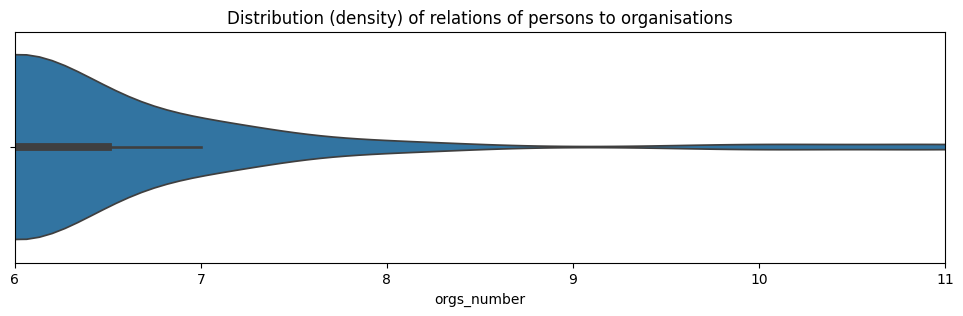

In [100]:
# Plot the distribution of eigenvector density

df=gr_memb[gr_memb.orgs_number>5]

min_val = df.orgs_number.min()
max_val = df.orgs_number.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df.orgs_number, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

## Most frequent organisations as relations

Organisations where memberships' relationship happen are different from those where people are educated and are employed, as we can see if we compare the tables below.

We therefore just join educational institutions and employment

In [101]:
### Study
gbe_edu.head(10)

,organisation_label,number
0,École Normale Supérieure,296
1,University of Vienna,215
2,University of Bonn,187
3,Italian School of Archaeology at Athens,120
4,Leipzig University,118
5,Ludwig-Maximilians-Universität München,117
6,École pratique des hautes études,109
7,Humboldt-Universität zu Berlin,97
8,Harvard University,86
9,Eötvös Loránd University,67


In [102]:
### Employment
gbe_empl.head(10)

,organisation_label,number
0,University of Vienna,921
1,Humboldt-Universität zu Berlin,747
2,Collège de France,513
3,Ludwig-Maximilians-Universität München,429
4,Heidelberg University,362
5,Sapienza University of Rome,355
6,University of Göttingen,351
7,University of Bonn,351
8,University of Tübingen,348
9,National Center for Scientific Research,346


In [103]:
### Join first hundred organisation for education and employment

gb_organ_of_rel=pd.merge(left=gbe_edu, on='organisation_label', right=gbe_empl,
                suffixes=('_rel_edu', '_rel_empl'), how='outer')
gb_organ_of_rel[['number_rel_edu','number_rel_empl']]=gb_organ_of_rel[['number_rel_edu','number_rel_empl']].fillna(0).astype('int')
print(len(gb_organ_of_rel))
gb_organ_of_rel.head()

147


,organisation_label,number_rel_edu,number_rel_empl
0,Aarhus University,0,15
1,Adam Mickiewicz University in Poznań,9,0
2,American School of Classical Studies at Athens,0,15
3,Antikensammlung Berlin,0,18
4,Balliol College,3,0


In [104]:
### Inspect most frequent organisations, order by study
gb_organ_of_rel.sort_values(by='number_rel_edu', ascending=False).iloc[:10]

,organisation_label,number_rel_edu,number_rel_empl
140,École Normale Supérieure,296,0
129,University of Vienna,215,921
87,University of Bonn,187,351
39,Italian School of Archaeology at Athens,120,0
44,Leipzig University,118,144
47,Ludwig-Maximilians-Universität München,117,429
146,École pratique des hautes études,109,240
30,Humboldt-Universität zu Berlin,97,747
28,Harvard University,86,175
16,Eötvös Loránd University,67,45


In [105]:
### Inspect most frequent organisations, order by employer
# Note the difference, e.g. the MSU Faculty of Physcs has no employee ... 
# There should be a bias in the data (not yet verified)
# See also CERN and Bell Labs
gb_organ_of_rel.sort_values(by='number_rel_empl', ascending=False).iloc[:30]


,organisation_label,number_rel_edu,number_rel_empl
129,University of Vienna,215,921
30,Humboldt-Universität zu Berlin,97,747
12,Collège de France,0,513
47,Ludwig-Maximilians-Universität München,117,429
29,Heidelberg University,36,362
72,Sapienza University of Rome,34,355
87,University of Bonn,187,351
104,University of Göttingen,55,351
127,University of Tübingen,36,348
60,National Center for Scientific Research,0,346


In [106]:
### Membership
# These are totally different institution with regard to the former ones
gbe_memb.head(10)

,organisation_label,number
0,German Archaeological Institute,101125
1,Académie des Inscriptions et Belles-Lettres,7598
2,Accademia Nazionale dei Lincei,5514
3,"Royal Swedish Academy of Letters, History and ...",3729
4,Academy of Sciences of Turin,2046
5,Royal Prussian Academy of Sciences,2042
6,Austrian Archaeological Institute,1417
7,Göttingen Academy of Sciences and Humanities i...,1385
8,American Academy of Arts and Sciences,1363
9,Society of Antiquaries of London,1273


## Merge the three networks: where do the encounters happen?

We merge the three tables of relations (education, employment, membership) and observe where encounters happen.

In [107]:
### Join educational and employment persons' pairs
# All relationships are kept, left and right join -> outer
network=pd.merge(gr_edu, gr_empl, on=['person_uri_x', 'person_uri_y', 'per_activ_x', 'per_activ_y'],
                 how='outer', suffixes=('_edu', '_empl'), indicator=True)
network.rename(columns={'_merge': 'merge_1'}, inplace=True)

In [108]:
print('Number of edu+empl pairs:',len(network))
network.sort_values(by='orgs_number_edu', ascending=False).head(2)

Number of edu+empl pairs: 11693


,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,orgs_uris_edu,per_activ_x,per_activ_y,orgs_labels_empl,orgs_number_empl,orgs_uris_empl,merge_1
10856,http://www.wikidata.org/entity/Q66001,http://www.wikidata.org/entity/Q67091,Humboldt-Universität zu Berlin|Leipzig Univers...,3.0,http://www.wikidata.org/entity/Q152087|http://...,1851-1875,1851-1875,Kiel University,1.0,http://www.wikidata.org/entity/Q156737,both
6966,http://www.wikidata.org/entity/Q19772325,http://www.wikidata.org/entity/Q571137,"Faculty of Arts, Charles University in Prague|...",3.0,http://www.wikidata.org/entity/Q3563550|http:/...,1926-1950,1926-1950,NaN,NaN,NaN,left_only


In [109]:
### Join to network the membership persons' pairs
# All relationships are kept, left and right join -> outer
network=pd.merge(network, gr_memb, on=['person_uri_x', 'person_uri_y', 'per_activ_x', 'per_activ_y' ],
                 how='outer', suffixes=('', '_memb'), indicator=True)
network.rename(columns={'orgs_labels': 'orgs_labels_memb','orgs_number': 'orgs_number_memb','organisation_uri': 'orgs_uris_memb'}, inplace=True)

In [110]:
network['orgs_number_edu'].fillna(0, inplace=True)
network['orgs_number_empl'].fillna(0, inplace=True)
network['orgs_number_memb'].fillna(0, inplace=True)
network['orgs_number_memb']=network['orgs_number_memb'].astype(int)
network['orgs_number_edu']=network['orgs_number_edu'].astype(int)
network['orgs_number_empl']=network['orgs_number_empl'].astype(int)
network=network[['person_uri_x', 'person_uri_y', 'orgs_labels_edu', 'orgs_number_edu', 'per_activ_x', 'per_activ_y', 'orgs_labels_empl', 'orgs_number_empl', 'orgs_labels_memb', 'orgs_number_memb']]

In [111]:
print('Number of edu+empl+memb pairs:',len(network))
network.iloc[550:555]

Number of edu+empl+memb pairs: 144150


,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,per_activ_x,per_activ_y,orgs_labels_empl,orgs_number_empl,orgs_labels_memb,orgs_number_memb
550,http://www.wikidata.org/entity/Q100213,http://www.wikidata.org/entity/Q1580989,NaN,0,1951-1975,1976-2000,NaN,0,German Archaeological Institute,1
551,http://www.wikidata.org/entity/Q100213,http://www.wikidata.org/entity/Q15816101,NaN,0,1951-1975,1976-2000,NaN,0,German Archaeological Institute,1
552,http://www.wikidata.org/entity/Q100213,http://www.wikidata.org/entity/Q15818627,NaN,0,1951-1975,1976-2000,NaN,0,German Archaeological Institute,1
553,http://www.wikidata.org/entity/Q100213,http://www.wikidata.org/entity/Q15819392,NaN,0,1951-1975,1976-2000,NaN,0,German Archaeological Institute,1
554,http://www.wikidata.org/entity/Q100213,http://www.wikidata.org/entity/Q15822293,NaN,0,1951-1975,1976-2000,NaN,0,German Archaeological Institute,1


In [112]:
### create field with sum of edu and empl
network['sum_edu_empl']=network['orgs_number_edu']+network['orgs_number_empl']

In [113]:
### create field with sum of all values
network['sum_all_rel']=network['orgs_number_edu']+network['orgs_number_empl']+network['orgs_number_memb']

#### Add persons' labels

In [114]:
network=pd.merge(left=network,right=df_p[['person_uri','labelPer','birthYear']], left_on='person_uri_x', right_on='person_uri')

In [115]:
network.drop(columns=['person_uri'], inplace=True)

In [116]:
network=pd.merge(left=network,right=df_p[['person_uri','labelPer','birthYear']], left_on='person_uri_y', right_on='person_uri', suffixes=('_x1', '_y'))


In [117]:
network.head(2)

,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,per_activ_x,per_activ_y,orgs_labels_empl,orgs_number_empl,orgs_labels_memb,orgs_number_memb,sum_edu_empl,sum_all_rel,labelPer_x1,birthYear_x1,person_uri,labelPer_y,birthYear_y
0,http://www.wikidata.org/entity/Q1001016,http://www.wikidata.org/entity/Q1032757,NaN,0,1926-1950,1951-1975,NaN,0,Hungarian Academy of Sciences,1,0,1,Nándor Fettich,1900,http://www.wikidata.org/entity/Q1032757,Gyula Hajnóczi,1920
1,http://www.wikidata.org/entity/Q1001016,http://www.wikidata.org/entity/Q1214364,Eötvös Loránd University,1,1926-1950,1926-1950,NaN,0,Hungarian Academy of Sciences,1,1,2,Nándor Fettich,1900,http://www.wikidata.org/entity/Q1214364,Lajos Nagy,1897


In [118]:
network.rename(columns={'labelPer_x1': 'labelPer_x','birthYear_x1': 'birthYear_x'}, inplace=True)

In [119]:
network.drop(columns=['person_uri'], inplace=True)

In [120]:
network.head(2)

,person_uri_x,person_uri_y,orgs_labels_edu,orgs_number_edu,per_activ_x,per_activ_y,orgs_labels_empl,orgs_number_empl,orgs_labels_memb,orgs_number_memb,sum_edu_empl,sum_all_rel,labelPer_x,birthYear_x,labelPer_y,birthYear_y
0,http://www.wikidata.org/entity/Q1001016,http://www.wikidata.org/entity/Q1032757,NaN,0,1926-1950,1951-1975,NaN,0,Hungarian Academy of Sciences,1,0,1,Nándor Fettich,1900,Gyula Hajnóczi,1920
1,http://www.wikidata.org/entity/Q1001016,http://www.wikidata.org/entity/Q1214364,Eötvös Loránd University,1,1926-1950,1926-1950,NaN,0,Hungarian Academy of Sciences,1,1,2,Nándor Fettich,1900,Lajos Nagy,1897


In [121]:
### Change columns order
network=network[['labelPer_x',
  'labelPer_y',
  'birthYear_x','birthYear_y',
'per_activ_x', 'per_activ_y',
 'sum_edu_empl', ### study and employment relationshipa
 'sum_all_rel', ### all the relationships
 'orgs_number_edu',  'orgs_labels_edu', 
 'orgs_number_empl', 'orgs_labels_empl',
 'orgs_number_memb', 'orgs_labels_memb',
 'person_uri_x', 'person_uri_y'
   ]]

In [122]:
### SQL Queries


# order by max sum of edu and empl relations
query_1="""
    SELECT *
    FROM network
    ORDER BY sum_edu_empl DESC
    LIMIT 5
"""


# order by max sum of all relations
query_2="""
    SELECT * 
    FROM network
    WHERE orgs_number_edu > 0
    AND orgs_number_empl>0
    ORDER BY sum_all_rel DESC
    --OFFSET 500
    LIMIT 10
"""

# order by max sum of all relations
query_2_count="""
    SELECT COUNT(*) as number  -- 3922
    FROM network
    WHERE orgs_number_edu > 0
    AND orgs_number_empl>0
"""

# order by max  edu and empl relations
query_3="""
    SELECT *
    FROM network
    WHERE orgs_number_edu > 0
    AND orgs_number_empl>0
    ORDER BY orgs_number_empl DESC, orgs_number_edu DESC
    --OFFSET 500
    LIMIT 10
"""

In [123]:
duckdb.query(query_2).to_df()

,labelPer_x,labelPer_y,birthYear_x,birthYear_y,per_activ_x,per_activ_y,sum_edu_empl,sum_all_rel,orgs_number_edu,orgs_labels_edu,orgs_number_empl,orgs_labels_empl,orgs_number_memb,orgs_labels_memb,person_uri_x,person_uri_y
0,Otto Hirschfeld,Otto Benndorf,1843,1838,1876-1900,1876-1900,5,8,2,University of Bonn|University of Göttingen,3,University of Göttingen|University of Vienna|C...,3,Austrian Academy of Sciences|Royal Prussian Ac...,http://www.wikidata.org/entity/Q69297,http://www.wikidata.org/entity/Q74197
1,Alexander Conze,Otto Benndorf,1831,1838,1876-1900,1876-1900,3,8,1,University of Göttingen,2,University of Göttingen|University of Vienna,5,German Archaeological Institute|Göttingen Acad...,http://www.wikidata.org/entity/Q72857,http://www.wikidata.org/entity/Q74197
2,André Caquot,Jean Leclant,1923,1920,1951-1975,1951-1975,5,7,2,École Normale Supérieure|École pratique des ha...,3,Collège de France|University of Paris|École pr...,2,Société Asiatique|Académie des Inscriptions et...,http://www.wikidata.org/entity/Q2847438,http://www.wikidata.org/entity/Q329349
3,Ernst Curtius,Karl Richard Lepsius,1814,1810,1851-1875,1851-1875,2,7,1,University of Göttingen,1,Humboldt-Universität zu Berlin,5,American Academy of Arts and Sciences|Göttinge...,http://www.wikidata.org/entity/Q61407,http://www.wikidata.org/entity/Q77231
4,Rudolf Wagner,Friedrich Wieseler,1805,1811,1826-1850,1851-1875,2,7,1,University of Göttingen,1,University of Göttingen,5,Saint Petersburg Academy of Sciences|Russian A...,http://www.wikidata.org/entity/Q65860,http://www.wikidata.org/entity/Q91993
5,Ernst Curtius,Friedrich Wieseler,1814,1811,1851-1875,1851-1875,2,7,1,University of Göttingen,1,University of Göttingen,5,Göttingen Academy of Sciences and Humanities i...,http://www.wikidata.org/entity/Q61407,http://www.wikidata.org/entity/Q91993
6,Otto Jahn,Karl Müllenhoff,1813,1818,1851-1875,1851-1875,4,6,3,Humboldt-Universität zu Berlin|Leipzig Univers...,1,Kiel University,2,Göttingen Academy of Sciences and Humanities i...,http://www.wikidata.org/entity/Q66001,http://www.wikidata.org/entity/Q67091
7,Paul-Marie Duval,Raymond Bloch,1912,1914,1951-1975,1951-1975,3,6,1,École Normale Supérieure,2,École française de Rome|École pratique des hau...,3,German Archaeological Institute|Société nation...,http://www.wikidata.org/entity/Q3370354,http://www.wikidata.org/entity/Q3420680
8,Ernest Will,Jean Leclant,1913,1920,1951-1975,1951-1975,3,6,2,University of Strasbourg|École Normale Supérieure,1,University of Paris,3,Société nationale des Antiquaires de France|Br...,http://www.wikidata.org/entity/Q20641846,http://www.wikidata.org/entity/Q329349
9,Werner Jobst,Robert Fleischer,1945,1941,1976-2000,1976-2000,3,5,1,University of Vienna,2,University of Vienna|Austrian Archaeological I...,2,Mommsen Society|German Archaeological Institute,http://www.wikidata.org/entity/Q20948026,http://www.wikidata.org/entity/Q2157102


In [124]:
print('Tot:', len(network), 'Edu:', len
      (gr_edu), ', Empl:', len(gr_empl), ', Memb:', len(gr_memb))

Tot: 144150 Edu: 2377 , Empl: 9659 , Memb: 137358


### Store the network on the disk

DO NOT COMMIT THIS FILE IF NOT ADDED *.pkl  TO .gitignore

In [125]:
### BEWARE: add all pickle files to the .gitignore file with this entry . *.pkl

### DO NOT COMMIT THIS FILE IF NOT ADDED *.pkl  TO .gitignore

file_address='../da6_data/da6-networks.pkl'
network.to_pickle(file_address)

## Correlations

We could wonder if the fact of studying together, or working together would lead to be member of the same organisations.

Given the large amount of people having just one or to relation, we only consider people having at least four relationships.

We use here ranking correlation given that we are counting relations

Surprisingly:
* there is some weak positive relation between studying and working together
* but there is a stronger negative correlation between studying or working together and being member of same organisations 


In [126]:
### ONLY EXECUTE if you need to restart the notebook from the stored network

file_address='../da6_data/da6-networks.pkl'
network=pd.read_pickle(file_address)
print(len(network))
network.iloc[:3]

144150


,labelPer_x,labelPer_y,birthYear_x,birthYear_y,per_activ_x,per_activ_y,sum_edu_empl,sum_all_rel,orgs_number_edu,orgs_labels_edu,orgs_number_empl,orgs_labels_empl,orgs_number_memb,orgs_labels_memb,person_uri_x,person_uri_y
0,Nándor Fettich,Gyula Hajnóczi,1900,1920,1926-1950,1951-1975,0,1,0,NaN,0,NaN,1,Hungarian Academy of Sciences,http://www.wikidata.org/entity/Q1001016,http://www.wikidata.org/entity/Q1032757
1,Nándor Fettich,Lajos Nagy,1900,1897,1926-1950,1926-1950,1,2,1,Eötvös Loránd University,0,NaN,1,Hungarian Academy of Sciences,http://www.wikidata.org/entity/Q1001016,http://www.wikidata.org/entity/Q1214364
2,Nándor Fettich,Géza Supka,1900,1883,1926-1950,1926-1950,0,1,0,NaN,0,NaN,1,Hungarian Academy of Sciences,http://www.wikidata.org/entity/Q1001016,http://www.wikidata.org/entity/Q1292574


In [127]:
### Inspect cooccurrence of pairs, before analysing correlations

# We observe that we have quite sparse data in the network !

print('Total number of relationships:',len(network))
print('Edu', len(network[(network.orgs_number_edu>0)]))
print('Empl', len(network[(network.orgs_number_empl>0)]))
print('Memb', len(network[(network.orgs_number_memb>0)]))
print('Study and work together',len(network[(network.orgs_number_edu>0) & (network.orgs_number_empl>0)]))
print('Study and membership together', len(network[(network.orgs_number_edu>0) & (network.orgs_number_memb>0) ]))
print('Work and membership together',len(network[ (network.orgs_number_empl>0) & (network.orgs_number_memb>0) ]))
print('All three phases together',len(network[(network.orgs_number_edu>0) & (network.orgs_number_empl>0) & (network.orgs_number_memb>0) ]))

Total number of relationships: 144150
Edu 2377
Empl 9659
Memb 137358
Study and work together 343
Study and membership together 1061
Work and membership together 4044
All three phases together 204


In [128]:
### We only consider in the distribution more than three
df=network[network.sum_all_rel>5].copy(deep=True)
print(len(df))
print(df.sum_all_rel.describe())

72
count    72.000000
mean      6.486111
std       0.903718
min       6.000000
25%       6.000000
50%       6.000000
75%       7.000000
max      11.000000
Name: sum_all_rel, dtype: float64


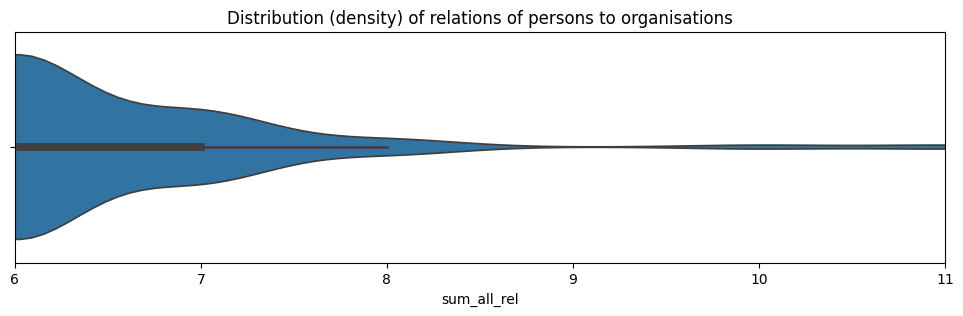

In [129]:

### Plot the distribution of the total number of relations
# where there are more than 3 relations
min_val = df.sum_all_rel.min()
max_val = df.sum_all_rel.max()

plt.figure(figsize=(12, 3))
ax = sns.violinplot(data=df.sum_all_rel, orient='h')

# Set the y-axis limits to exactly match the data range
ax.set_xlim(min_val, max_val)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.title('Distribution (density) of relations of persons to organisations')
plt.show()

### Measure the correlations

#### Relationships in studies and in employment

We only can use rank correlation given these are counts. 

Also, most educational relations have count: 1 - so the correlation does not really make sense

In [130]:
predictor_name='orgs_number_edu' # 'orgs_number_edu' 'orgs_number_empl'
dependent_name='orgs_number_empl'

# Prepare variables
X = df[predictor_name]
Y = df[dependent_name]

# 1. Correlation Analysis: on ranking because these are counts
spearman_corr, p_val_spearman = spearmanr(X, Y)

print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_val_spearman:.4f})")


Spearman Correlation: 0.4492 (p-value: 0.0001)


#### Relationships in studies and in membership

In [131]:

predictor_name='orgs_number_edu' # 'orgs_number_edu' 'orgs_number_empl'
dependent_name='orgs_number_memb'

# Prepare variables
X = df[predictor_name]
Y = df[dependent_name]

# 1. Correlation Analysis: on ranking because these are counts
spearman_corr, p_val_spearman = spearmanr(X, Y)

print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_val_spearman:.4f})")


Spearman Correlation: -0.5944 (p-value: 0.0000)


#### Relationships in employment and in membership

In [132]:

predictor_name='orgs_number_empl' # 'orgs_number_edu' 'orgs_number_empl'
dependent_name='orgs_number_memb'

# Prepare variables
X = df[predictor_name]
Y = df[dependent_name]

# 1. Correlation Analysis
spearman_corr, p_val_spearman = spearmanr(X, Y)

print(f"Spearman Correlation: {spearman_corr:.4f} (p-value: {p_val_spearman:.4f})")


Spearman Correlation: -0.7673 (p-value: 0.0000)


### Represent the correlations

In [133]:
df=df[['sum_all_rel', 'orgs_number_edu', 
       'orgs_number_empl', 'orgs_number_memb']].\
              sort_values(by=['orgs_number_memb'])
df.reset_index(inplace=True, drop=True)
df.head()

,sum_all_rel,orgs_number_edu,orgs_number_empl,orgs_number_memb
0,7,2,3,2
1,6,3,1,2
2,7,0,4,3
3,6,2,1,3
4,6,1,2,3


In [134]:
# Smooth with gliding mean

# Ensure data is sorted by index (and value)

df['smoothed_memb'] = df['orgs_number_memb'].rolling(window=100, min_periods=1).mean()
df['smoothed_empl'] = df['orgs_number_empl'].rolling(window=100, min_periods=5).mean()
df['smoothed_edu'] = df['orgs_number_edu'].rolling(window=100, min_periods=1).mean()
df['smoothed_all'] = df['sum_all_rel'].rolling(window=100, min_periods=1).mean()



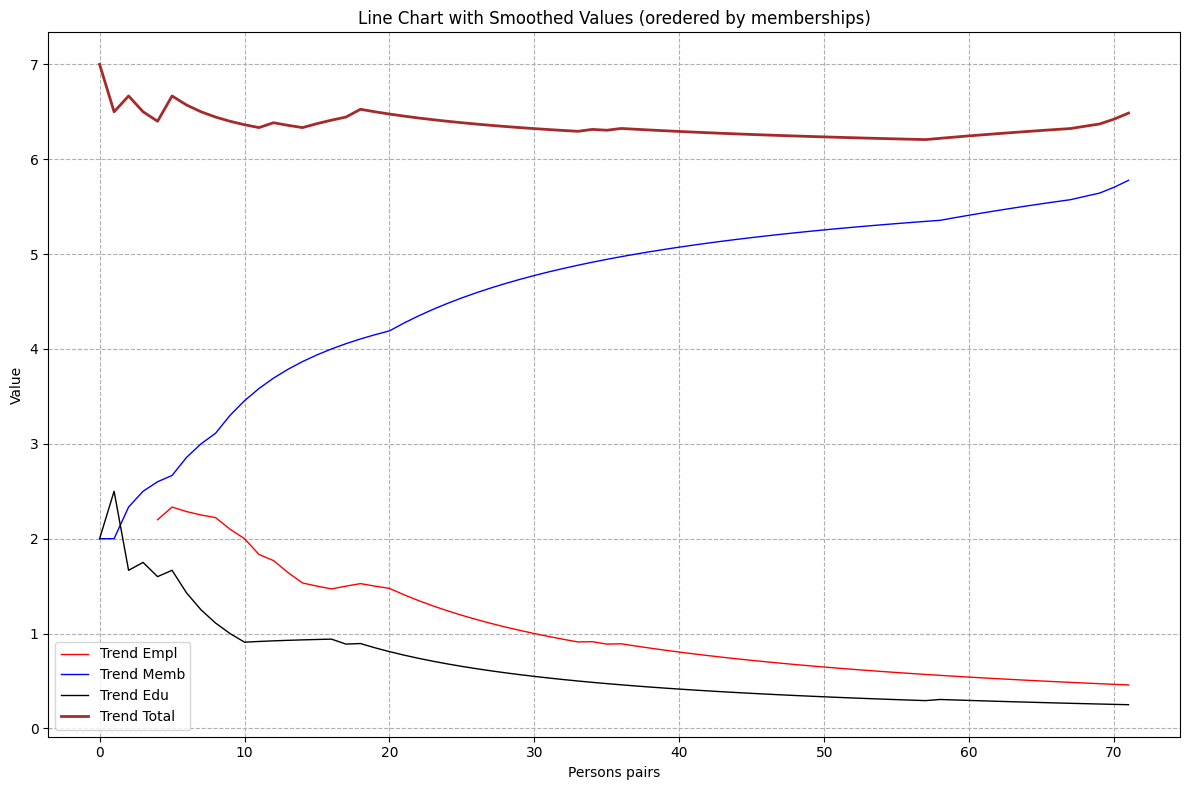

In [135]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(df['smoothed_empl'], linestyle='-', color='red', linewidth=1, label='Trend Empl')
ax.plot(df['smoothed_memb'],  linestyle='-', color='blue', linewidth=1, label='Trend Memb')
ax.plot(df['smoothed_edu'],  linestyle='-', color='black', linewidth=1, label='Trend Edu')
ax.plot(df['smoothed_all'],  linestyle='-', color='brown', linewidth=2, label='Trend Total')

ax.set_xlabel('Persons pairs')
ax.set_ylabel('Value')
ax.set_title('Line Chart with Smoothed Values (oredered by memberships)')
ax.grid(True, linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()